###  This notebook is used to optimize Hyperparameters of GradientBoostingRegressor() predicting SRP [%] redfield normalized concentrations:

In [ ]:
# load required moduls:

# load required moduls:
# pandas is used for data manipulation:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error
from sklearn import metrics
from numpy import mean
from numpy import std
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold
import os

In [ ]:
# define the output folder path:

output_folder = '../../../output_data/ML_analysis/hyperparameter_settings'

# Check if the folder exists, if not, create it:
if not os.path.exists(output_folder):
    os.makedirs(output_folder)


#### 1. import data:

In [ ]:
nutrient_export_data = pd.read_csv('../../../output_data/input_ML_learning_temp/median_cnp_export_abs_conc_and_rfr_and_basin_feat.csv').drop(columns='Unnamed: 0')

In [3]:
#nutrient_export_data.info()

## Prepare the data for the machine learning models:

1. Split data into features and targets
2. Convert data frame to arrays 
3. Split data into training and test set

1. Function to prepare input data: split data into target and features and convert to arrays: 

In [4]:

def create_input_ML(data, target_var):

    # create array with exported nutrient values, which are our target values, we want to predict 
    target = np.array(nutrient_export_data[target_var])


    # remove the labels from the features df:

    features = nutrient_export_data.drop(['HYBAS_ID', 'n_imbal', 'p_imbal', 'c_imbal', 'median_DOC_TOC_bioav', 'median_DIN', 'median_SRP'], axis = 1)
    #features = nutrient_export_data.filter(items=selected_features)

    #select columns by index: 
    features= features.iloc[:,:]
    features.columns

    # save feature list for later use:
    feature_list = list(features.columns)

    # convert to numpy array:
    features = np.array(features)

    return target, features, feature_list

### Apply create_input_ML function: set data and target_var

In [5]:
# choose target var: "n_imbal", "p_imbal" or "c_imbal":
target_var = "p_imbal"

# data:
data = nutrient_export_data

In [6]:
target, features, feature_list = create_input_ML(data = data, target_var = target_var)

In [7]:
len(feature_list)

33

### Split data into training and testing set: 

### set test_size and random_state

In [8]:
# test size: usually 0.2 or 0.25:
test_size = 0.2
#set random_state:
random_state = 41 # before I used random_state=41


In [9]:

# using Skicit-learn to split data into training and testing sets:
from sklearn.model_selection import train_test_split

train_features, test_features, train_targets, test_targets = train_test_split(features, target, test_size = test_size, random_state = random_state) 



Check data structure: targets and features should have same length in training and test set:

In [10]:
print('Training Features Shape:', train_features.shape)
print('Training targets Shape:', train_targets.shape)
print('Testing Features Shape:', test_features.shape)
print('Testing targets Shape:', test_targets.shape)

Training Features Shape: (2796, 33)
Training targets Shape: (2796,)
Testing Features Shape: (700, 33)
Testing targets Shape: (700,)


### Box-Cox transformation of training and testing targets:

In [11]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='box-cox')

# Reshape train_targets to 2D if it's 1D
if len(train_targets.shape) == 1:
    train_targets2 = np.reshape(train_targets, (-1, 1))

# Fit the transformer to the training data
# This learns the best lambda value for each feature
pt.fit(train_targets2)

# Transform the training data using the learned lambda values
train_targets_transformed_bc = pt.transform(train_targets2)
# convert back to 1D format
train_targets_transformed_bc = train_targets_transformed_bc.ravel()

# Transform the test data using the same lambda values
# Reshape test_targets to 2D if it's 1D
if len(test_targets.shape) == 1:
    test_targets2 = np.reshape(test_targets, (-1, 1))

test_targets_transformed_bc = pt.transform(test_targets2)
test_targets_transformed_bc = test_targets_transformed_bc.ravel()

### Import model functions from sklearn:

In [12]:
# import models
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn import metrics


# Fit Boosting regression tree and random forest model: first with default parameters:

In [13]:
def_parms_brt = {
    "n_estimators": 7000,
    "max_depth": 9,
    "min_samples_split": 5,
    "learning_rate": 0.001, # before i had 0.005
    "loss": "squared_error",
    "subsample": 0.5,
}


def_parms_rf = {
    "n_estimators": 6000,
    "max_depth": 4,
}

model = "brt"

cross_val = RepeatedKFold(n_splits=2, n_repeats=2, random_state=1)


### fit Gradient Boosting Regressor with default parameters: 

In [14]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
from datetime import datetime
import os

def run_model_def_parms(model, parms, target_var, train_features, test_features, train_targets, test_targets, cross_val):
    
    if target_var == "n_imbal":
        comp = "DIN"
    if target_var == "p_imbal":
        comp = "SRP"
    if target_var == "c_imbal":
        comp = "OC"
    
    
    if model == "brt":
        ml_model = GradientBoostingRegressor(**parms,  random_state = 5)
    if model == "rf":
        ml_model = RandomForestRegressor(**parms)

    
    #n_scores = cross_val_score(ml_model, train_features, train_targets, scoring='r2', cv=cross_val, n_jobs=4, error_score='raise')
    #print('Cross validation R2: %.3f (%.3f)' % (mean(n_scores), std(n_scores)))


    # Train the model on all training data: 
    ml_model.fit(train_features, train_targets);

    # evaluate model with test data:
    predictions = ml_model.predict(test_features)

    # pred on training data: 
    pred_train = ml_model.predict(train_features)

    if model == "brt":
        test_score = np.zeros((parms["n_estimators"],), dtype=np.float64)
        for i, y_pred in enumerate(ml_model.staged_predict(test_features)):
            test_score[i] = mean_squared_error(test_targets, y_pred)

        fig = plt.figure(figsize=(6, 6))
        plt.subplot(1, 1, 1)
        plt.title("Deviance")
        plt.plot(
            np.arange(parms["n_estimators"]) + 1,
            ml_model.train_score_,
            "b-",
            label="Training Set Deviance",
            )
        plt.plot(
            np.arange(parms["n_estimators"]) + 1, test_score, "r-", label="Test Set Deviance"
            )
        plt.legend(loc="upper right")
        plt.xlabel("Boosting Iterations")
        plt.ylabel("Deviance")
        fig.tight_layout()
        plt.show()

    
    # plot predictions on training data and testing data:

    # first training data:
    
    plt.scatter(train_targets, pred_train) 
    plt.xlabel(f"Actual concentration of {target_var} [%]", fontsize=12)
    plt.ylabel(f"Predicted concentration of {target_var} [%]", fontsize=12)
    plt.title(f" Training data model: {str(model)} predicting {target_var}", fontsize=14)
    r2 = r2_score(train_targets, pred_train)
    # add line of linear model
    
    plt.plot(test_targets, test_targets, color='red', linestyle='--', label=f'R^2 = {r2:.2f}')  # Linie mit der Form y = x zeichnen
    plt.legend()
    plt.show()
            

    
    
    #now testing data:
    plt.scatter(test_targets, predictions) 
    plt.xlabel(f"Actual concentration of {target_var} [%]", fontsize=12)
    plt.ylabel(f"Predicted concentration of {target_var} [%]", fontsize=12)
    plt.title(f" Testing data model: {str(model)} predicting {target_var}", fontsize=14)
    r2 = r2_score(test_targets, predictions)
    # add line of linear model
    
    plt.plot(test_targets, test_targets, color='red', linestyle='--', label=f'R^2 = {r2:.2f}')  # Linie mit der Form y = x zeichnen
    plt.legend()
    plt.show()

    r2_test = r2_score(test_targets, predictions)
    r2_test
    
    MAPE = mean_absolute_percentage_error(test_targets, predictions)
    print(f"Model: {str(model)} --> MAPE = {MAPE*100.0:.2f}")
    
    mse = mean_squared_error(test_targets, ml_model.predict(test_features))
    print("The mean squared error (MSE) on test set: {:.4f}".format(mse))
    
    mae = mean_absolute_error(test_targets, ml_model.predict(test_features))
    print("The mean absolute error (MAE) on test set: {:.4f}".format(mae))

    # return fitted model:
    return ml_model



    

In [16]:
model_fitted = run_model_def_parms(model = model, target_var = target_var, train_features = train_features, test_features = test_features , train_targets = train_targets_transformed_bc, test_targets = test_targets_transformed_bc, cross_val = cross_val, parms = def_parms_brt)

### Define a function to write infos of fitted model to csv file:

In [ ]:
%load_ext autoreload
%autoreload 2
import sys
import os
sys.path.append('../')
from functions_ml_analysis import info_fitted_model_to_csv  

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [111]:
info_fitted_model_to_csv(fitted_model = model_fitted, target_var = 'p_imbal', train_features = train_features, test_features = test_features, train_targets = train_targets_transformed_bc, test_targets = test_targets_transformed_bc)

Did you transform the target variables? (yes/no)


Type yes/no: yes


Which function was used to  transform the targets? box-cox, log?


Transformation function: box-cox


box-cox
Add a comment about the fitted model if you like? Optimized model? Optimization algorithm?


Type in any comment: base parms again


True


### Fit the model with same parameters as above but use early stopping if loss is not improving by adding more trees:

In [113]:
gbm_early_stopping = GradientBoostingRegressor(
    **def_parms_brt,
    random_state = 5,
    validation_fraction=0.1,
    n_iter_no_change= int(def_parms_brt['n_estimators']* 0.1), #use 10 percent of n_estimators
)

gbm_early_stopping.fit(train_features, train_targets_transformed_bc)

preds_test = gbm_early_stopping.predict(test_features)
print(f"R2_score{r2_score(test_targets_transformed_bc, preds_test):2f}")
print(f"MAPE = {mean_absolute_percentage_error(test_targets_transformed_bc, preds_test):2f}")
print(f"MSE = {mean_squared_error(test_targets_transformed_bc, preds_test):2f}")
print(f"MAE ={mean_absolute_error(test_targets_transformed_bc, preds_test):2f}")

R2_score0.362318
MAPE = 1.962653
MSE = 0.632731
MAE =0.602417


In [114]:
gbm_early_stopping.n_estimators_

6408

In [115]:
info_fitted_model_to_csv(fitted_model = gbm_early_stopping, target_var = target_var, train_features = train_features, test_features = test_features, train_targets = train_targets_transformed_bc, test_targets = test_targets_transformed_bc)

Did you transform the target variables? (yes/no)


Type yes/no: yes


Which function was used to  transform the targets? box-cox, log?


Transformation function: box-cox


box-cox
Add a comment about the fitted model if you like? Optimized model? Optimization algorithm?


Type in any comment: early stopping after 6408 trees


True


In [20]:
#run_model_def_parms(model = "rf", target_var = target_var, train_features = train_features, test_features = test_features , train_targets = train_targets, test_targets = test_targets, cross_val = cross_val, parms = def_parms_rf)

### Apply parameter tuning using RandomizedSearchCV():

In [17]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
model = GradientBoostingRegressor(random_state = 5) 


# define the evaluation procedure
from sklearn.model_selection import RepeatedKFold
cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)
from scipy.stats import loguniform


# define scoring functions:

scoring = {"R2": "r2", "MAE": "neg_mean_absolute_error"}


# set parameter ranges
params_random = {'max_depth':  np.arange(5, 14), 
         #'min_samples_leaf': np.arange(2, 11),
          'max_features': np.arange(2, 33),
         "subsample": np.arange(0.5,1, 0.1),
        "learning_rate":loguniform(a=1e-3, b=1e0), #np.linspace(start = 0.001, stop = 0.4, num = 1200),
        "n_estimators":np.arange(1000, 8000, 50)}

gridrandom = RandomizedSearchCV(estimator = model,
                                param_distributions = params_random,
                                cv= cv, 
                                verbose= 10, 
                                n_jobs= 60,
                                refit = "R2",
                                scoring = scoring,
                                return_train_score=True,
                                n_iter = 2500,
                                #validation_fraction=0.1, seem not to work
                                #n_iter_no_change=700,
                                )
                                

# summarize the best score and configuration
#print("Best: %f using %s" % (gridsearch_result.best_score_, gridsearch_result.best_params_)) # summarize all scores that were evaluated
#means = gridsearch_result.cv_results_['mean_test_score']
#stds = grid_result.cv_results_['std_test_score']
#params = grid_result.cv_results_['params']
#for mean, stdev, param in zip(means, stds, params):
 #   print("%f (%f) with: %r" % (mean, stdev, param))

In [18]:
params_random

{'max_depth': array([ 5,  6,  7,  8,  9, 10, 11, 12, 13]),
 'max_features': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
        19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]),
 'subsample': array([0.5, 0.6, 0.7, 0.8, 0.9]),
 'learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen at 0x20125ccfc10>,
 'n_estimators': array([1000, 1050, 1100, 1150, 1200, 1250, 1300, 1350, 1400, 1450, 1500,
        1550, 1600, 1650, 1700, 1750, 1800, 1850, 1900, 1950, 2000, 2050,
        2100, 2150, 2200, 2250, 2300, 2350, 2400, 2450, 2500, 2550, 2600,
        2650, 2700, 2750, 2800, 2850, 2900, 2950, 3000, 3050, 3100, 3150,
        3200, 3250, 3300, 3350, 3400, 3450, 3500, 3550, 3600, 3650, 3700,
        3750, 3800, 3850, 3900, 3950, 4000, 4050, 4100, 4150, 4200, 4250,
        4300, 4350, 4400, 4450, 4500, 4550, 4600, 4650, 4700, 4750, 4800,
        4850, 4900, 4950, 5000, 5050, 5100, 5150, 5200, 5250, 5300, 5350,
        5400, 5450, 5500, 5550, 56

In [ ]:
%%time
# search_result = 
gridrandom.fit(train_features, train_targets_transformed_bc)

Fitting 30 folds for each of 2500 candidates, totalling 75000 fits


In [2]:
print(gridrandom.best_params_)
print(gridrandom.best_score_)

In [89]:
# apply optimized model:

preds_test = gridrandom.predict(test_features)

preds_train = gridrandom.predict(train_features)

In [3]:
from sklearn.metrics import r2_score
r2_score(train_targets_transformed_bc, preds_train)

In [4]:

print(f"R2_score{r2_score(test_targets_transformed_bc, preds_test):2f}")
print(f"MAPE = {mean_absolute_percentage_error(test_targets_transformed_bc, preds_test):2f}")
print(f"MSE = {mean_squared_error(test_targets_transformed_bc, preds_test):2f}")
print(f"MAE ={mean_absolute_error(test_targets_transformed_bc, preds_test):2f}")

In [5]:
plt.scatter(test_targets_transformed_bc, preds_test) 
plt.xlabel(f"Actual concentration of {target_var} [%]", fontsize=12)
plt.ylabel(f"Predicted concentration of {target_var} [%]", fontsize=12)
plt.title(f" Testing data model: {str(model)} predicting {target_var}", fontsize=14)
r2 = r2_score(test_targets_transformed_bc, preds_test)
 # add line of linear model
    
plt.plot(test_targets_transformed_bc, test_targets_transformed_bc, color='red', linestyle='--', label=f'R^2 = {r2:.2f}')  # Linie mit der Form y = x zeichnen
plt.legend()
plt.show()

NameError: name 'plt' is not defined

In [6]:
plt.scatter(train_targets_transformed_bc, preds_train) 
plt.xlabel(f"Actual concentration of {target_var} [%]", fontsize=12)
plt.ylabel(f"Predicted concentration of {target_var} [%]", fontsize=12)
plt.title(f" Training data model: {str(model)} predicting {target_var}", fontsize=14)
r2 = r2_score(train_targets_transformed_bc, preds_train)
# add line of linear model
    
plt.plot(test_targets_transformed_bc, test_targets_transformed_bc, color='red', linestyle='--', label=f'R^2 = {r2:.2f}')  # Linie mit der Form y = x zeichnen
plt.legend()
plt.show()
            

NameError: name 'plt' is not defined

In [94]:
info_fitted_model_to_csv(fitted_model = gridrandom, target_var = target_var, train_features = train_features, test_features = test_features, train_targets = train_targets_transformed_bc, test_targets = test_targets_transformed_bc)

Did you transform the target variables? (yes/no)


Type yes/no: no


Add a comment about the fitted model if you like? Optimized model? Optimization algorithm?


Type in any comment: RandomizedSearchCV computation time 1d 20h


True


### Now calculate importances of factors:

In [73]:
# create array with exported nutrient values, which are our target values, we want to predict 
#target = np.array(nutrient_export_data['c_imbal'])
target = nutrient_export_data['p_imbal']

# remove the labels from the features df:

features = nutrient_export_data.drop(['HYBAS_ID', 'n_imbal', 'p_imbal', 'c_imbal', 'median_DOC_TOC_bioav', 'median_DIN', 'median_SRP'], axis = 1)
#features = nutrient_export_data.filter(items=selected_features)

#select columns by index: 
features= features.iloc[:,0:43]
features.columns

# save feature list for later use:
feature_list = list(features.columns)


In [76]:
params = {}
brt = GradientBoostingRegressor(**params)
brt.fit(train_features, train_targets)

GradientBoostingRegressor(learning_rate=0.0039949958298582154, max_depth=12,
                          max_features=7, n_estimators=4650, subsample=0.7)

In [77]:
pred_test_test = brt.predict(test_features)
r2_score(test_targets, pred_test_test)

0.5218504976565512

In [78]:

 
brt_model = GradientBoostingRegressor()

In [1]:
#run_model_def_parms(model = "brt", target_var = 'n_imbal', train_features = train_features, test_features = test_features , train_targets = train_targets, test_targets = test_targets, cross_val = cross_val, parms = params_optimum)

In [80]:
test_features

,latitude,UP_AREA,twi90,slp_dg_uav,for_pc_use,crp_pc_use,pst_pc_use,urb_pc_use,ppd_pk_uav,dis_m3_pyr_perkm2,...,pac_pc_use,cly_pc_uav,slt_pc_uav,snd_pc_uav,soc_th_uav,swc_pc_uyr,kar_pc_use,ero_kh_uav,hft_ix_u09,gdp_ud_usu
623,50.577670,2633.4,8.250140,51,32,22,16,11,201.006,0.008960,...,10,18,40,42,57,84,2,399,181,2.711684e+10
612,50.661788,188.9,7.794398,40,49,14,16,10,168.987,0.009815,...,21,18,38,44,60,86,0,204,187,1.302874e+09
2022,47.558233,123.0,7.628797,53,47,0,0,78,1055.992,0.032496,...,1,10,35,55,68,80,0,439,364,6.980393e+09
1565,51.021641,2227.5,8.276541,45,38,34,12,22,330.870,0.008099,...,20,16,36,48,63,81,0,358,249,2.793465e+10
854,48.588566,199.9,7.535500,70,52,21,15,29,388.120,0.012086,...,56,21,41,38,46,85,30,486,235,4.427457e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
770,49.320328,625.5,13.242063,78,62,23,4,15,242.073,0.008902,...,6,17,37,46,52,79,0,226,197,4.889315e+09
2906,33.922562,123.3,8.949726,21,52,3,1,80,546.646,0.016342,...,0,19,35,46,33,80,0,634,338,3.051751e+09
973,47.633760,661.5,11.612109,55,47,16,26,6,143.546,0.026603,...,25,18,38,43,46,97,0,334,161,4.568648e+09
2361,41.169597,366.1,9.157913,14,2,47,31,0,3.426,0.003261,...,4,23,43,34,18,50,0,5191,87,3.977334e+07


In [82]:
from sklearn.inspection import permutation_importance

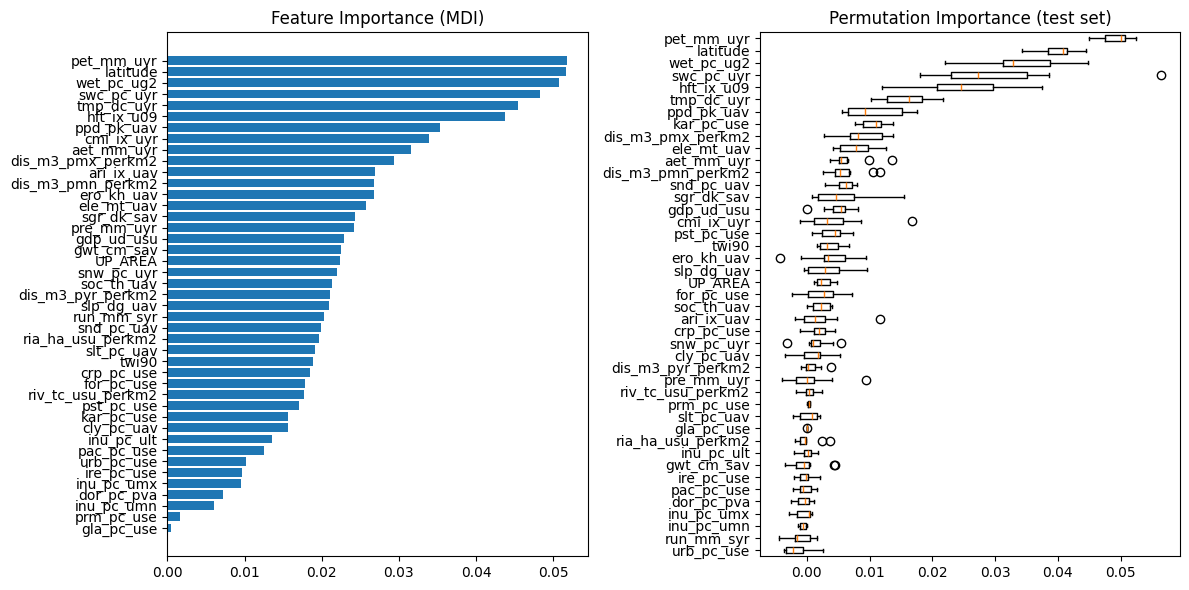

In [83]:
feature_importance = brt.feature_importances_
sorted_idx = np.argsort(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + 0.5
fig = plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.barh(pos, feature_importance[sorted_idx], align="center")
plt.yticks(pos, np.array(feature_list)[sorted_idx])
plt.title("Feature Importance (MDI)")

result = permutation_importance(
    brt, test_features, test_targets, n_repeats=10, random_state=42, n_jobs=2
)
sorted_idx = result.importances_mean.argsort()
plt.subplot(1, 2, 2)
plt.boxplot(
    result.importances[sorted_idx].T,
    vert=False,
    labels=np.array(feature_list)[sorted_idx],
)
plt.title("Permutation Importance (test set)")
fig.tight_layout()
plt.show()